# Assess model performance from pre-trained model

In [14]:
import subprocess
import sys
import os
try:
    import torch_geometric
    print("torch_geometric is already installed.")
except ImportError:
    print("torch_geometric is not installed. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric"])
    print("torch_geometric has been installed.")

# add path 
module_path = os.path.abspath(os.path.join('.', 'VortexNet'))
print(module_path)
if module_path not in sys.path:
    sys.path.append(module_path)    

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from VortexNet.model import GNN4

# Import DataParser #uncommon for datascaler
from dataParser import DataParser


import json

plt.rcParams['font.size'] = 25

plt.rcParams.update({
    "axes.titlesize": 30,
    "axes.labelsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
})



torch_geometric is already installed.
/home/yiren/Desktop/MF-VortexNet/scripts/VortexNet


# plot

In [15]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_field_distribution(VD, cp, title='Pressure Distribution', min=None, max=None, ax=None, cbar=False, cmap=None, norm= None):
    # Ensure cp is a 1D array
    plt.rcParams.update({
        "font.family": "Helvetica",
        "font.size": 17
    })
    if cp.ndim > 1:
        cp = cp.squeeze(0)

    if min is None:
        vmin = np.min(cp)
    else:
        vmin = min

    if max is None:
        vmax = np.max(cp)
    else:
        vmax = max

    # If no axes are provided, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Normalize the pressure coefficient values to the range [vmin, vmax]
    if norm == None:
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
    if cmap == None:
        cmap = plt.get_cmap('viridis')
    scalar_map = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

    # Plot the panels and fill with cp data
    for i in range(len(VD.XA1)):
        x = [VD.XA1[i], VD.XB1[i], VD.XB2[i], VD.XA2[i], VD.XA1[i]]
        y = [VD.YA1[i], VD.YB1[i], VD.YB2[i], VD.YA2[i], VD.YA1[i]]

        # Get the color for the current pressure coefficient value
        cp_value = cp[i]
        color = scalar_map.to_rgba(cp_value)

        # Fill the panel with the corresponding cp value
        polygon = plt.Polygon(np.column_stack((x, y)), closed=True, facecolor=color, edgecolor=(0, 0, 0, 0.1))
        ax.add_patch(polygon)

    ax.set_title(title)
    #ax.set_xlabel('X [m]')
    #ax.set_ylabel('Y [m]')
    ax.axis('off')
    ax.set_xlim(np.min(VD.XA1)-0.01, np.max(VD.XB2)+0.01)
    ax.set_ylim(np.min(VD.YA1)-0.01, np.max(VD.YB2)+0.01)
    ax.margins(x=0.002)  # Reduce extra whitespace on X-axis
    # set bounds to tight

    # Return the scalar map for consistent color bar
    if cbar:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)  # Append space for color bar
        cbar_obj = plt.colorbar(scalar_map, cax=cax)
        cbar_obj.set_label(r'$\Delta C_p$')
        return scalar_map
    return scalar_map


# Import model

In [ ]:

weights_name = '20260217_022011'

# Specify the path to the trained weights file
weights_path = "/path/to/your/moodel/weights/model_weights_{}.pth".format(weights_name)
scaler_path_pkl = "/path/to/your/model/scaler/scaler_{}.pth".format(weights_name)





HIDDEN_CHANNELS = 63
HEADS= 4
PENALTY_WEIGHT=0.025689113034518467
DROPOUT_WEIGHT=0.08504544001617964
LAMBDA=5.8267381175451374e-05
ALPHA=0.009705552281881635
HOP=10
MAX_PHY_LOSS=0.4175220124520909


# fixed hyperparameters
noise = 0.03
CLIP_VALUE = 30
node_in_channels = 11
edge_in_channels = 1
out_channels = 1
device = 'cuda'
REF_RE = 10**7
Ref_Length = 0.435762
random_seeds = 21
model = GNN4(node_in_channels, edge_in_channels, HIDDEN_CHANNELS, out_channels, num_coarse=None, \
             num_fine=None, dropout_rate=DROPOUT_WEIGHT, HEADS = HEADS, ALPHA=ALPHA, HOP=HOP ).to(device)

model.load_state_dict(torch.load(weights_path))

print("***Model loaded from \n {}".format(weights_path))


# Load and process data using DataParser
directory_path = '/path/to/your/dataset/*.pkl/file/root'

# DataParser configuration parameters (match the training configuration)
root_chord_ref = 0.6536436                      # root chord length, chacteristic length for normalization
apex_x, apex_y, apex_z = 0.0, 0.0, 0.0          # wing apex location, for centering coordinates around the apex

# Create DataParser instance
parser = DataParser(
    directory_path=directory_path,
    ref_re=REF_RE,
    ref_length=Ref_Length,
    root_chord_ref=root_chord_ref,
    apex_x=apex_x,
    apex_y=apex_y,
    apex_z=apex_z,
    test_size=0.3,
    random_state=random_seeds,  # Matching random_seeds=21 from original code
    device=device,
    use_robust_scaler=False,  # Using new standardization with RobustScaler
    normalize_coordinates=True
)

# Try to load scaler from training if it exists

scaler_data = None
if os.path.exists(scaler_path_pkl):
    print(f"Loading scaler from {scaler_path_pkl}")
    scaler_data = DataParser.load_scaler(scaler_path_pkl)
    # Apply loaded scaler configuration to parser
    parser.scaler = scaler_data['scaler']
    parser.use_robust_scaler = scaler_data['use_robust_scaler']
    parser.features_to_normalize_indices = scaler_data['features_to_normalize_indices']
    parser.features_to_keep_indices = scaler_data['features_to_keep_indices']
    parser.normalize_coordinates = scaler_data['normalize_coordinates']
    parser.root_chord_ref = scaler_data['root_chord_ref']
    parser.apex_x = scaler_data['apex_x']
    parser.apex_y = scaler_data['apex_y']
    parser.ref_re = scaler_data['ref_re']
    parser.ref_length = scaler_data['ref_length']
    print("Scaler loaded successfully")
else:
    print(f"Scaler file not found at {scaler_path_pkl}, will fit new scaler from data")

# Process data: load, split, prepare, and normalize
print("\nProcessing data with DataParser...")
parser.load_data()
parser.split_data()
parser.prepare_datasets()

# If scaler was loaded, apply it; otherwise normalize_data will fit a new one
if scaler_data is not None:
    # Apply loaded scaler to datasets
    print("Applying loaded scaler to datasets...")
    # Convert each tensor in the list to NumPy arrays
    nn_training_set_np = [parser.to_numpy(data) for data in parser.nn_training_set]
    nn_test_set_np = [parser.to_numpy(data) for data in parser.nn_test_set]
    
    # Apply scaler to training set
    nn_training_set_scaled_np = []
    for data in nn_training_set_np:
        features_to_normalize = data[:, parser.features_to_normalize_indices]
        features_normalized = parser.scaler.transform(features_to_normalize)
        
        if parser.use_robust_scaler:
            features_normalized_processed = features_normalized.copy()
            features_normalized_processed[:, 1:9] = np.tanh(features_normalized[:, 1:9])
        else:
            features_normalized_processed = features_normalized
        
        features_to_keep = data[:, parser.features_to_keep_indices]
        reconstructed = np.hstack([features_normalized_processed, features_to_keep])
        nn_training_set_scaled_np.append(reconstructed)
    
    # Apply scaler to test set
    nn_test_set_scaled_np = []
    for data in nn_test_set_np:
        features_to_normalize = data[:, parser.features_to_normalize_indices]
        features_normalized = parser.scaler.transform(features_to_normalize)
        
        if parser.use_robust_scaler:
            features_normalized_processed = features_normalized.copy()
            features_normalized_processed[:, 1:9] = np.tanh(features_normalized[:, 1:9])
        else:
            features_normalized_processed = features_normalized
        
        features_to_keep = data[:, parser.features_to_keep_indices]
        reconstructed = np.hstack([features_normalized_processed, features_to_keep])
        nn_test_set_scaled_np.append(reconstructed)
    
    # Update Data objects with normalized node features
    for i, data in enumerate(parser.nn_training_set):
        data.x = torch.tensor(nn_training_set_scaled_np[i], device=data.x.device, dtype=torch.float)
    
    for i, data in enumerate(parser.nn_test_set):
        data.x = torch.tensor(nn_test_set_scaled_np[i], device=data.x.device, dtype=torch.float)
else:
    # Fit new scaler and normalize
    parser.normalize_data()

# Get the processed datasets
nn_training_set = parser.nn_training_set
nn_test_set = parser.nn_test_set
train_set = parser.training_set
test_set = parser.test_set
mf_results = parser.mf_results  # Make mf_results available for later cells

# Print summary of the training and test set 
print("\n******Summary of the Training and Test Datasets******")
print(f"Number of training samples: {len(nn_training_set)}")
print(f"Number of test samples: {len(nn_test_set)}")
print(f"Number of features: {nn_training_set[0].num_features}")
print(f"Number of edge features: {nn_training_set[0].num_edge_features}")
print(f"Number of nodes: {nn_training_set[0].num_nodes}")
print(f"Number of edges: {nn_training_set[0].num_edges}")

model.eval()




/home/yiren/Desktop/cnfrevision/signloss/cnfvortexnetff/signloss_hpo/model_weights_20260217_022011.pth
/home/yiren/Desktop/cnfrevision/signloss/cnfvortexnetff/signloss_hpo/tuning_results_20260217_022011.json
***Model loaded from 
 /home/yiren/Desktop/cnfrevision/signloss/cnfvortexnetff/signloss_hpo/model_weights_20260217_022011.pth
Loading scaler from /home/yiren/Desktop/cnfrevision/signloss/cnfvortexnetff/signloss_hpo/scaler_20260217_022011.pth
Scaler loaded from /home/yiren/Desktop/cnfrevision/signloss/cnfvortexnetff/signloss_hpo/scaler_20260217_022011.pth
Scaler loaded successfully

Processing data with DataParser...
Total number of runs: 600
Size of the training set: 420
Size of the test set: 180
******Assembled Training Dataset Shapes******
control_points shape : (420, 900, 3)
vlm_dcp shape : (420, 1, 900)
cfd_dcp shape : (420, 1, 900)
cfd_ff shape : (420, 900, 3)
vlm_slope_span_u shape : (420, 1, 900)
vlm_slope_chord_u shape : (420, 1, 900)
vlm_curvature_u shape : (420, 1, 900)
v

GNN4(
  (node_encoder): Linear(in_features=11, out_features=3969, bias=True)
  (edge_encoder): Linear(in_features=1, out_features=63, bias=True)
  (conv_layers): ModuleList(
    (0): GATv2Conv(3969, 63, heads=4)
    (1-8): 8 x GATv2Conv(252, 63, heads=4)
    (9): GATv2Conv(252, 1, heads=1)
  )
  (norm_layers): ModuleList(
    (0-8): 9 x BatchNorm(252)
    (9): BatchNorm(1)
  )
  (skip_linear_layers): ModuleDict(
    (0): Linear(in_features=252, out_features=1, bias=True)
    (1): None
    (2): None
    (3): None
    (4): None
  )
)

Test loss: 0.0107
(900,)
Test 3 Predicted, AoA: 12.71, Mach: 0.44 dcp
Re: 9.42e+06


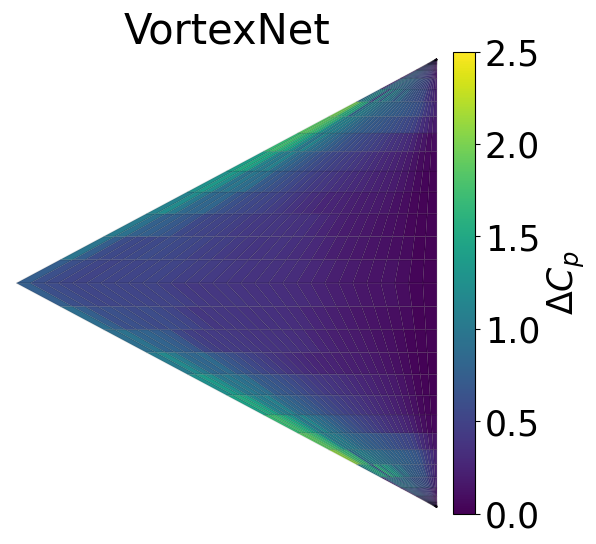

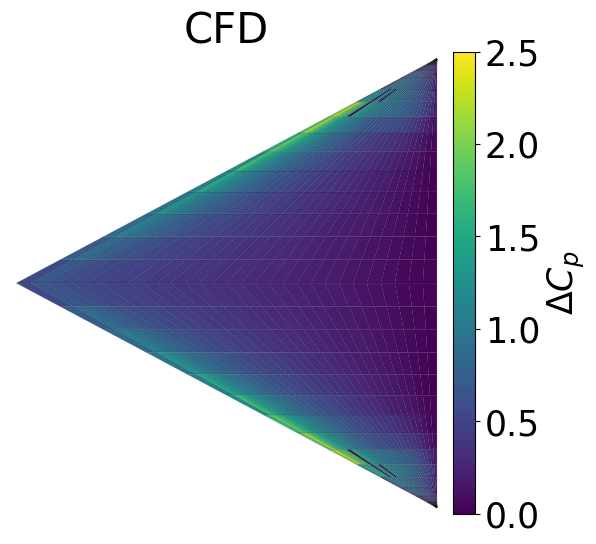

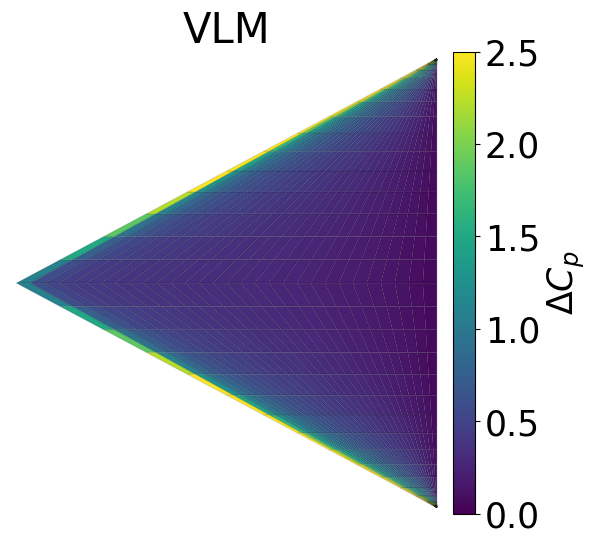

In [20]:
# Evaluate the model on the test set
test_loss = 0
for data in nn_test_set:
    data = data.to(device)
    with torch.no_grad():
        output = model(data)
        test_loss += F.mse_loss(output, data.y).item()

test_loss /= len(test_set)
print(f'Test loss: {test_loss:.4f}')
# Plot the results for a random index
test_index = np.random.randint(len(test_set))
data = nn_test_set[test_index].to(device)

with torch.no_grad():
    output = model(data).cpu().numpy().reshape(-1)
    print(output.shape)
    print(f"Test {test_index} Predicted, AoA: {test_set[test_index].alpha}, Mach: {test_set[test_index].mach} dcp")
    plot_field_distribution(test_set[test_index].vlm_vd, np.array(output), 
                            title=f"VortexNet",
                            min=0, max=2.5, cbar=True)
    plot_field_distribution(test_set[test_index].vlm_vd, np.array(test_set[test_index].cfd_data),
                            title=f"CFD",
                            min=0, max=2.5, cbar=True)
    plot_field_distribution(test_set[test_index].vlm_vd, np.array(test_set[test_index].vlm_data),
                            title=f"VLM",
                            min=0, max=2.5, cbar=True)
    print(f"Re: {test_set[test_index].Re:.2e}")
